In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [2]:
# --- parameters ---
lam = 3.0    # arrival rate (visits per hour)
T   = 10.0   # observation window (hours)

The exponential distribution has the density function:

f(x) = λ · e^(−λx)

In [3]:
# inter-arrival times are Exponential with mean 1/lam
# if X ~ Exp(lam), then E[X] = 1/lam
inter_arrivals = rng.exponential(scale=1/lam, size=1000)

If the times between events are Exp(λ), then, the count of events in [0,T] is Poisson(λT)

In [4]:
# cumulative sum turns intervals into positions in time
arrivals = np.cumsum(inter_arrivals)

# keep only arrivals that fall within the observation window
arrivals = arrivals[arrivals <= T]

N = len(arrivals)
print(f"Simulated arrivals : N(T) = {N}")
print(f"Expected  E[N(T)]  = λ·T = {lam * T:.1f}")

Simulated arrivals : N(T) = 32
Expected  E[N(T)]  = λ·T = 30.0


### Layer 1 — Visualization

Top panel: the counting process N(t) — how visits accumulate over time.
Bottom panel: the individual events on the timeline.

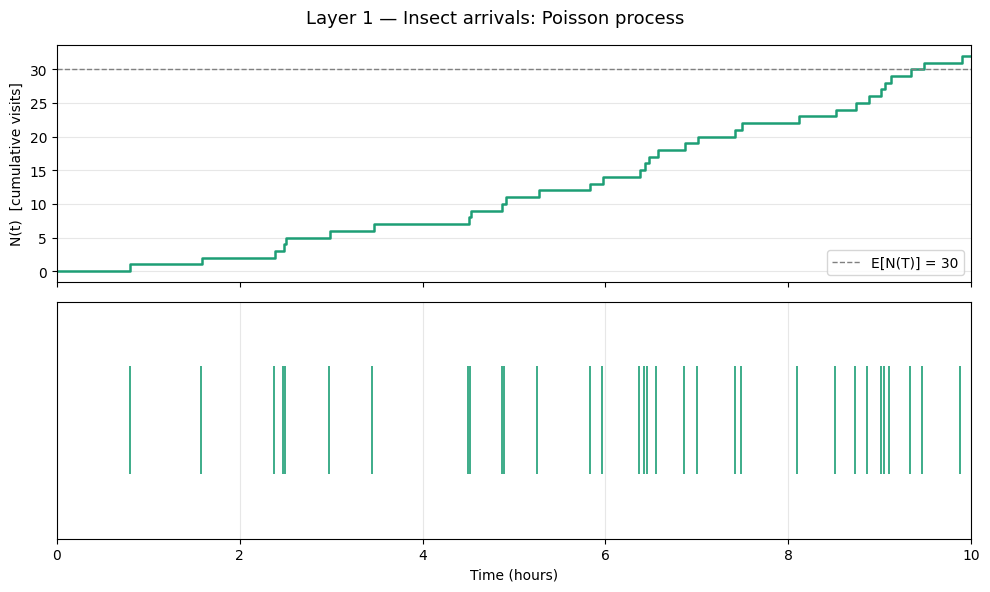

In [5]:
# --- build the counting process ---
t_grid = np.linspace(0, T, 500) # time points to evaluate N(t)
N_t    = np.searchsorted(arrivals, t_grid, side='right')

# --- plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle("Layer 1 — Insect arrivals: Poisson process", fontsize=13)

# counting process
axes[0].step(t_grid, N_t, where='post', color='#1D9E75', linewidth=1.8)
axes[0].axhline(lam * T, color='gray', linestyle='--', linewidth=1,
                label=f"E[N(T)] = {lam * T:.0f}")
axes[0].set_ylabel("N(t)  [cumulative visits]")
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# event timeline
axes[1].eventplot(arrivals, lineoffsets=0, linelengths=0.6,
                  color='#1D9E75', linewidth=1.2)
axes[1].set_yticks([])
axes[1].set_xlabel("Time (hours)")
axes[1].set_xlim(0, T)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Layer 2 — Thinning

Not every visit results in a trap closure.
Each arrival is kept with probability p — this encodes the full activation chain:
entering the trap, touching a hair, touching again within the time window.

By the thinning property of Poisson processes:
if arrivals ~ Poisson(λT), then closures ~ Poisson(λpT)

In [6]:
# --- thinning parameter ---
p = 0.4    # probability of closure given a visit

# --- flip a coin for each arrival ---
coin_flips = rng.random(size=len(arrivals))
closures   = arrivals[coin_flips < p]

M = len(closures)
print(f"Total arrivals  : N(T) = {N}")
print(f"Closures        : M(T) = {M}")
print(f"Expected M(T)   = λ·p·T = {lam * p * T:.1f}")

Total arrivals  : N(T) = 32
Closures        : M(T) = 15
Expected M(T)   = λ·p·T = 12.0


#### Why does `coin_flips < p` work?

`rng.random()` generates one number uniformly between 0 and 1 for each arrival.

Uniform means every value in [0, 1] is equally likely.
So the probability of landing below any threshold p is exactly p.

For example, with p = 0.4:

    coin_flips = [0.71, 0.23, 0.88, 0.12, 0.55, ...]
    coin_flips < 0.4 → [False, True, False, True, False, ...]

The arrivals where the result is True become closures.
The arrivals where the result is False are ignored — the insect walked away.

This is exactly a Bernoulli trial with success probability p,
applied independently to each arrival.

And by the thinning property of Poisson processes:
if we thin a Poisson(λ) process by keeping each event with probability p,
the surviving events form a new Poisson process with rate λp.

So:
    arrivals ~ Poisson(λT)
    closures ~ Poisson(λpT)

Two independent Poisson processes, one nested inside the other.

### Layer 2.1 — Visualization

We plot both processes together:
- all arrivals in green (same as Layer 1)
- closures in red — the thinned subset

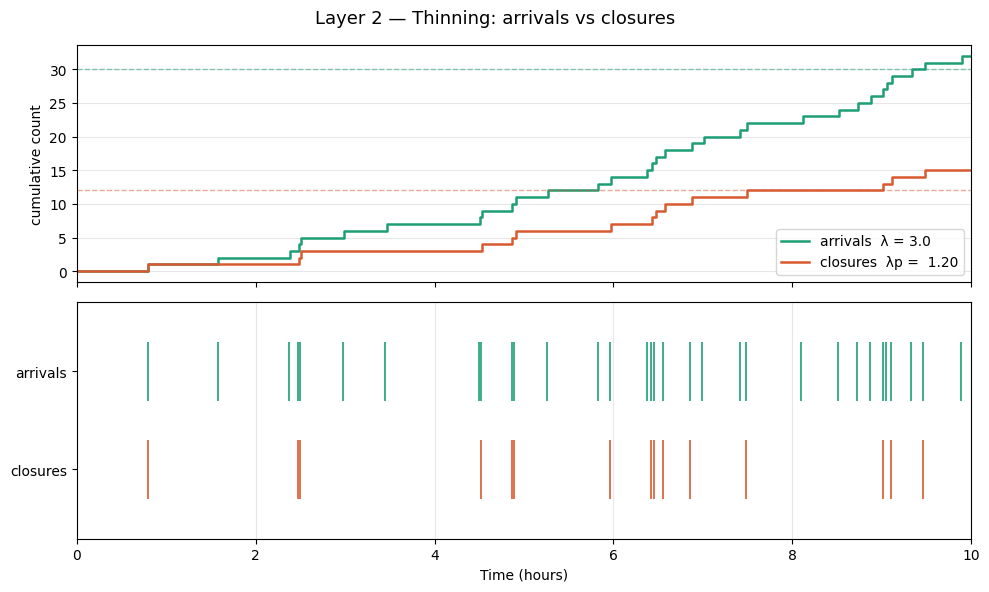

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle("Layer 2 — Thinning: arrivals vs closures", fontsize=13)

# counting processes
t_grid = np.linspace(0, T, 500)
N_t    = np.searchsorted(arrivals, t_grid, side='right')
M_t    = np.searchsorted(closures, t_grid, side='right')

axes[0].step(t_grid, N_t, where='post', color='#1D9E75', linewidth=1.8,
             label=f"arrivals  λ = {lam}")
axes[0].step(t_grid, M_t, where='post', color='#D85A30', linewidth=1.8,
             label=f"closures  λp = {lam * p: .2f}")
axes[0].axhline(lam * T,     color='#1D9E75', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axhline(lam * p * T, color='#D85A30', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_ylabel("cumulative count")
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# event timelines
axes[1].eventplot(arrivals, lineoffsets=1, linelengths=0.6,
                  color='#1D9E75', linewidth=1.2, label='arrivals')
axes[1].eventplot(closures, lineoffsets=0, linelengths=0.6,
                  color='#D85A30', linewidth=1.2, label='closures')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['closures', 'arrivals'], fontsize=10)
axes[1].set_xlabel("Time (hours)")
axes[1].set_xlim(0, T)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Closures are a sparse subset of arrivals

Every closure was first an arrival.
But not every arrival becomes a closure.

The closures sit on the same timeline, but there are fewer of them.
They can only appear where an arrival already happened.

---

**What makes a subset "sparse"?**

Two things:

**1. Fewer events**
p = 0.4 means roughly 40% of arrivals survive.
If arrivals gave us N events, closures give us around N·p.
The rest did not activate the trap.

**2. Same random structure**
The surviving events do not form some weird irregular process.
They form a clean Poisson process again, just with a lower rate:

    arrivals ~ Poisson(λ · T)
    closures ~ Poisson(λ · p · T)

---

**Why is that not obvious?**

Because you are randomly deleting events from a sequence.
You might expect the result to look patchy or irregular.
But it doesn't — it stays Poisson.

That is the thinning property:
a random independent thinning of a Poisson process
is still a Poisson process.

The randomness is preserved. Only the rate changes.

## Layer 3 — Value function V(τ)

The plant faces a tradeoff:

- closing captures prey → nutrient benefit B
- closing costs energy → cost C
- closing on a false positive → wasted effort

We model the expected value per unit time as:

    V(p) = λ · [B · q(p) - C · p]

where:
- p     = probability of closure given a visit (our thinning parameter)
- q(p)  = probability that a closure actually captures real prey
- B     = nutritional benefit per real capture
- C     = energetic cost per closure

The plant cannot control λ — that's the environment.
What evolution "tunes" is effectively p — the sensitivity of the trap.

The question is: what value of p maximizes V(p)?

In [11]:
# --- parameters ---
B = 10.0   # benefit per real capture
C = 3.0    # cost per closure

# --- assume q(p) = p  (higher sensitivity → more real captures) ---
# but also more false positives, so gains are sublinear
q = lambda p: p * (1 - p)   # peaks somewhere in the middle

# --- value function ---
p_grid = np.linspace(0, 1, 500)
V      = lam * (B * q(p_grid) - C * p_grid)

### Why q(p) = p(1-p)?

p and q are not complementary — they live on different events.
p = probability of closure given a visit.
q = probability of real capture given a closure.

When p is very low: the trap barely closes, almost no captures.
When p is very high: the trap closes on everything, too many false positives.

So q should be low at both extremes and peak somewhere in the middle.
p(1-p) is the simplest function with that shape.
It is a modeling assumption — not the only choice, but a clean one.

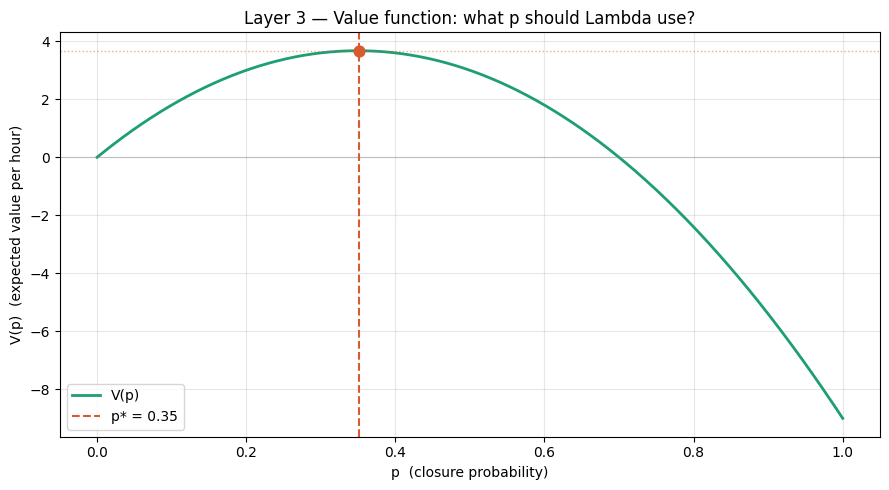

Optimal p*     = 0.35
Maximum V(p*)  = 3.67


In [12]:
# --- find optimal p ---
p_star = p_grid[np.argmax(V)]
V_star = V.max()

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(p_grid, V, color='#1D9E75', linewidth=2, label='V(p)')
ax.axvline(p_star, color='#D85A30', linestyle='--', linewidth=1.5,
           label=f'p* = {p_star:.2f}')
ax.axhline(V_star, color='#D85A30', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(0,      color='gray',    linestyle='-', linewidth=0.8, alpha=0.4)

ax.scatter([p_star], [V_star], color='#D85A30', zorder=5, s=60)

ax.set_xlabel("p  (closure probability)")
ax.set_ylabel("V(p)  (expected value per hour)")
ax.set_title("Layer 3 — Value function: what p should Lambda use?")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal p*     = {p_star:.2f}")
print(f"Maximum V(p*)  = {V_star:.2f}")

### Reading the value function

**Left side (p close to 0)**
The trap almost never closes.
Lambda (yes, I named my plant lambda) captures nothing — slow starvation.
V(p) approaches zero.

**Right side (p close to 1)**
The trap closes on everything.
Energy cost dominates.
Lambda exhausts itself on false positives.
V(p) crashes into negative territory.

**The peak at p* = 0.35**
This is the sweet spot.
Not too sensitive, not too picky.
Closes enough to capture real prey,
but discriminating enough to avoid wasting energy.

---

**The curve is asymmetric.**

It drops much faster on the right than on the left.

Being too trigger-happy is much worse for Lambda
than being slightly too cautious.

Which makes biological sense:
a plant that wastes energy dies faster
than one that occasionally misses a meal.

## Layer 4 — Optimization under constraints

So far we found p* by eyeballing the peak of V(p).
But we can solve for it analytically.

Taking the derivative of V(p) and setting it to zero:

    V(p)  = λ · [B · p(1-p) - C · p]
    V'(p) = λ · [B(1 - 2p) - C] = 0

Solving:

    B(1 - 2p) = C
    1 - 2p    = C/B
    p*        = (1 - C/B) / 2

So the optimal p depends only on the ratio C/B —
the cost of closing relative to the benefit of capturing.

---

But there is a real biological constraint:
the trap can only close a limited number of times before it wears out.
Venus fly traps typically survive 3-7 closures per trap lobe.

So Lambda does not just maximize V(p) freely —
she maximizes it subject to:

    E[closures] = λ · p · T  ≤  K

where K is the maximum number of closures Lambda can afford.

This is a constrained optimization problem.

In [15]:
# --- analytical solution ---
p_analytical = (1 - C/B) / 2
print(f"Analytical p*  = {p_analytical:.2f}")
print(f"Numerical  p*  = {p_star:.2f}")

# --- constraint: max K closures over T ---
K = 5.0   # Lambda can afford 5 closures in T hours

# constrained p: λ · p · T ≤ K  →  p ≤ K / (λ · T)
p_max       = K / (lam * T)
p_star_con  = min(p_analytical, p_max)

print(f"\nMax affordable p  = {p_max:.2f}")
print(f"Constrained p*    = {p_star_con:.2f}")

Analytical p*  = 0.35
Numerical  p*  = 0.35

Max affordable p  = 0.17
Constrained p*    = 0.17


### The constraint is binding

Free optimum:       p* = 0.35
Constrained p*:     p* = 0.17

The wear constraint cuts Lambda's optimal closure probability in half.

This means Lambda cannot afford to be as sensitive as she would like.
She has to be more conservative — not because sensitivity is bad,
but because each closure costs something irreversible:
mechanical wear on the trap.

This is exactly the tradeoff a venus fly trap faces in nature.
A young trap can afford slightly more risk.
An old trap near the end of its closure budget
should be much more conservative.

The constraint is not a limitation on the model.
It is the most biological part of it.

### Layer 4.1 — Visualization

The same value function V(p), but now with both optimal points:
- the free optimum p* = 0.35  — what Lambda would choose with no constraints
- the constrained p* = 0.17   — what Lambda can actually afford

The gap between them is the cost of wearing out.

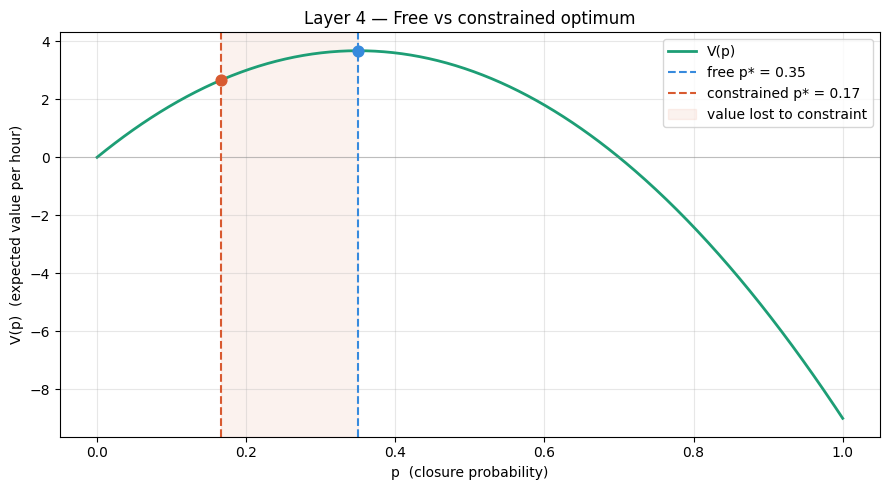

V(free p*)        = 3.68
V(constrained p*) = 2.67
Value lost        = 1.01


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

# --- value function ---
ax.plot(p_grid, V, color='#1D9E75', linewidth=2, label='V(p)')
ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)

# --- free optimum ---
ax.axvline(p_analytical, color='#378ADD', linestyle='--', linewidth=1.5,
           label=f'free p* = {p_analytical:.2f}')
ax.scatter([p_analytical], [lam * (B * q(p_analytical) - C * p_analytical)],
           color='#378ADD', zorder=5, s=60)

# --- constrained optimum ---
ax.axvline(p_star_con, color='#D85A30', linestyle='--', linewidth=1.5,
           label=f'constrained p* = {p_star_con:.2f}')
ax.scatter([p_star_con], [lam * (B * q(p_star_con) - C * p_star_con)],
           color='#D85A30', zorder=5, s=60)

# --- shade the gap ---
ax.axvspan(p_star_con, p_analytical, alpha=0.08, color='#D85A30',
           label='value lost to constraint')

ax.set_xlabel("p  (closure probability)")
ax.set_ylabel("V(p)  (expected value per hour)")
ax.set_title("Layer 4 — Free vs constrained optimum")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- value lost ---
V_free = lam * (B * q(p_analytical) - C * p_analytical)
V_con  = lam * (B * q(p_star_con)   - C * p_star_con)
print(f"V(free p*)        = {V_free:.2f}")
print(f"V(constrained p*) = {V_con:.2f}")
print(f"Value lost        = {V_free - V_con:.2f}")